# Blank Sample Anomaly Detection — MVP

## 1. Introduction

This notebook presents an end-to-end MVP workflow for detecting anomalies in Blank QC sample data exported from the CCLAS 6 Laboratory Information Management System.

### What are Blank samples?

Blank samples are a quality control mechanism used by mineral analysis laboratories to detect contamination, background signal, or analytical carryover introduced during sampling, preparation, or instrument analysis. Because a Blank sample contains little or none of the analyte being measured, its reported result should remain close to zero or below the method detection limit under normal conditions. An unexpectedly high Blank result may indicate that contamination has entered the process.

### Why standard statistics are not sufficient

Blank data is typically concentrated near zero with occasional large positive outliers. This means the distribution is heavily right-skewed and does not follow a normal (Gaussian) distribution. Methods that rely on the mean and standard deviation — such as standard Z-scores — are sensitive to those large outliers and will produce misleading thresholds. This notebook therefore uses **median-based robust statistics** throughout.

### What this notebook detects

| Anomaly Type | What it means | Detection Method |
|---|---|---|
| Point anomaly | A single Blank result that is unusually high relative to similar samples | Robust Z-score (MAD-based) |
| Collective anomaly | The Blank baseline gradually rising over time, indicating developing contamination | Rolling median drift |
| Contextual anomaly | Unusual Blank behaviour associated with a specific instrument | Instrument-level median comparison |

### Assumptions and limitations

- Blank records are identified using `ANALYTICAL_TYPE = Blank`.
- Results are expected to remain near zero with low variation under normal conditions.
- Shift-based contextual analysis is not possible because no shift field exists in the dataset.
- All outputs are **candidate anomalies for analyst review** — they do not confirm contamination, background signal, or analytical carryover.
- A conservative Isolation Forest contamination rate of 1% is used to minimise false positives, which may cause unnecessary laboratory shutdowns or rework.


## 2. Libraries and Setup

The following libraries are required for this notebook:

- **pandas** and **numpy**: data loading, cleaning, and feature engineering.
- **matplotlib**: visualisation of Blank distributions, drift trends, and anomaly summaries.
- **sklearn.ensemble.IsolationForest**: unsupervised machine learning anomaly detection.
- **IPython.display**: inline display of DataFrames within the notebook.

`RANDOM_STATE` is fixed to ensure that Isolation Forest results are reproducible across runs.


In [3]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display
from sklearn.ensemble import IsolationForest

RANDOM_STATE = 42

print("Libraries loaded successfully.")


Libraries loaded successfully.


## 3. Dataset Validation

Before loading the data, the notebook confirms that the source file exists and that all columns required for Blank anomaly analysis are present.

### Required columns

| Column | Purpose |
|---|---|
| `ANALYTICAL_TYPE` | Identifies Blank records for extraction |
| `NUMERIC_FINAL_VALUE` | The reported Blank measurement — primary detection target |
| `INTERNAL_TARGET_VALUE` | Expected Blank value (typically zero or near-zero) |
| `ANALYSED_DATE` | Required for chronological ordering and drift detection |
| `SCHEME_CODE` | Ensures only results from the same analytical method are compared |
| `ANALYTE_CODE` | Separates results for different chemical elements |
| `UNIT_CODE` | Ensures results are compared in the same unit |
| `INSTRUMENT_CODE` | Supports contextual anomaly detection by instrument |

Missing columns will raise an error before any analysis begins. This prevents silent failures caused by column name differences between CCLAS export versions.


In [4]:
REQUIRED_COLUMNS = [
    "ANALYTICAL_TYPE",
    "SAMPLE_NAME_ANON",
    "JOB_NAME_ANON",
    "NUMERIC_FINAL_VALUE",
    "INTERNAL_TARGET_VALUE",
    "ANALYSED_DATE",
    "SCHEME_CODE",
    "ANALYTE_CODE",
    "UNIT_CODE",
    "INSTRUMENT_CODE",
]

candidate_paths = [
    Path("data/QC_Sample_Data.csv"),
    Path.cwd() / "data/QC_Sample_Data.csv",
    Path.cwd().parent / "data/QC_Sample_Data.csv",
]

SOURCE_PATH = next(
    (path for path in candidate_paths if path.is_file()),
    None
)

if SOURCE_PATH is None:
    raise FileNotFoundError(
        "QC_Sample_Data.csv was not found. "
        "Place it in the same folder as the notebook."
    )

raw = pd.read_csv(SOURCE_PATH, low_memory=False)

# Normalise column names to prevent casing issues between export versions
raw.columns = raw.columns.str.strip().str.upper()

missing_columns = [col for col in REQUIRED_COLUMNS if col not in raw.columns]

if missing_columns:
    raise ValueError(f"Missing required columns: {missing_columns}")

# Parse dates explicitly — CCLAS exports can contain malformed hour values
raw["ANALYSED_DATE"] = pd.to_datetime(raw["ANALYSED_DATE"], errors="coerce")

print("Source file:", SOURCE_PATH.resolve())
print("Total dataset rows:", len(raw))
print("Columns available:", raw.columns.tolist())


Source file: /Users/ritumj/Documents/IFN735/Notebooks/data/QC_Sample_Data.csv
Total dataset rows: 1201152
Columns available: ['ANALYTICAL_TYPE', 'SAMPLE_NAME_ANON', 'JOB_NAME_ANON', 'NUMERIC_FINAL_VALUE', 'INTERNAL_TARGET_VALUE', 'ANALYSED_DATE', 'RECOVERY', 'SCHEME_CODE', 'SCHEME_VERSION', 'ANALYTE_CODE', 'RELATIVE_PERCENT_DIFFERENCE', 'STANDARD_STATUS', 'RECOVERY.1', 'PRECISION_STATUS', 'ANALYSED_BY_USER_ID', 'JOB_CLIENT_ID', 'UNIT_CODE', 'INSTRUMENT_CODE']


## 4. Blank Record Extraction

This step filters the full dataset to Blank QC records only, using `ANALYTICAL_TYPE = Blank`.

The notebook also performs three diagnostic checks at this stage:

1. **`< LOD` check**: determines whether any results were reported as below the limit of detection as text strings (e.g. `"<0.001"`). If present, these require censored-value modelling. In this dataset, none were found, so the numeric values are used directly.
2. **Missing target values**: counts rows where `INTERNAL_TARGET_VALUE` is absent. These rows can still be used for point-anomaly detection but cannot be used for target deviation calculations.
3. **Missing instrument codes**: counts rows where `INSTRUMENT_CODE` is absent. These rows are retained for point-anomaly and drift analysis but are excluded from instrument-specific contextual analysis.


In [5]:
# Extract Blank QC records
blank_df = raw[
    raw["ANALYTICAL_TYPE"]
    .astype(str)
    .str.strip()
    .str.casefold()
    .eq("blank")
].copy()

# Check for explicit < LOD text values
lod_count = (
    blank_df["NUMERIC_FINAL_VALUE"]
    .astype(str)
    .str.contains(r"^\s*<", regex=True, na=False)
    .sum()
)

missing_target_count = blank_df["INTERNAL_TARGET_VALUE"].isna().sum()
missing_instrument_count = blank_df["INSTRUMENT_CODE"].isna().sum()

print("Blank rows extracted:", len(blank_df))
print("Rows reported as < LOD:", lod_count)
print("Rows with missing target values:", missing_target_count)
print("Rows with missing instrument codes:", missing_instrument_count)

display(
    blank_df[[
        "ANALYTICAL_TYPE", "NUMERIC_FINAL_VALUE", "INTERNAL_TARGET_VALUE",
        "ANALYSED_DATE", "SCHEME_CODE", "ANALYTE_CODE", "UNIT_CODE", "INSTRUMENT_CODE",
    ]].head()
)


Blank rows extracted: 403601
Rows reported as < LOD: 0
Rows with missing target values: 1032
Rows with missing instrument codes: 192689


,ANALYTICAL_TYPE,NUMERIC_FINAL_VALUE,INTERNAL_TARGET_VALUE,ANALYSED_DATE,SCHEME_CODE,ANALYTE_CODE,UNIT_CODE,INSTRUMENT_CODE
2244,Blank,0.000000,0.0,2019-02-05 11:36:07,AR10_MS,TE,PPM,NaN
2851,Blank,-0.052295,0.0,2018-11-23 14:57:44,AR10_PATH,NI,PPM,NaN
2909,Blank,-0.001363,0.0,2018-11-23 14:57:44,AR10_PATH,MO,PPM,NaN
2910,Blank,1.599790,0.0,2018-11-23 14:56:04,AR10_PATH,ZN,PPM,NaN
2912,Blank,-0.619004,0.0,2018-11-23 14:57:44,AR10_PATH,AU,PPB,NaN


The preview confirms that the correct Blank records were extracted.

Key observations from this stage:
- Blank target values are typically zero, confirming that results should remain near zero under normal conditions.
- Reported results can be zero, negative, or small positive values. A non-zero result is not automatically anomalous — it must be compared with similar Blank results within the same scheme, analyte, and unit before a judgement is made.
- Missing `INSTRUMENT_CODE` values appear as `NaN`. These rows are retained for all other analysis steps.
- No explicit `< LOD` text values were found in this dataset, so censored-value modelling is not required.


## 5. Data Cleaning and Preparation

This step prepares the Blank dataset for analysis:

- **Numeric conversion**: `NUMERIC_FINAL_VALUE` and `INTERNAL_TARGET_VALUE` are coerced to float. Any non-numeric values (including residual text artefacts from the export) are converted to `NaN`.
- **Row removal**: rows missing the reported result, analysis date, scheme, analyte, or unit are removed. These fields are all required for valid Blank comparisons.
- **Instrument rows retained**: rows where `INSTRUMENT_CODE` is missing are kept for point-anomaly and drift analysis. They are only excluded from instrument-specific contextual checks later.
- **Chronological sorting**: the dataset is sorted by `ANALYSED_DATE` to support rolling baseline calculations in later steps.


In [6]:
blank_df["NUMERIC_FINAL_VALUE"] = pd.to_numeric(
    blank_df["NUMERIC_FINAL_VALUE"], errors="coerce"
)

blank_df["INTERNAL_TARGET_VALUE"] = pd.to_numeric(
    blank_df["INTERNAL_TARGET_VALUE"], errors="coerce"
)

REQUIRED_BLANK_COLUMNS = [
    "NUMERIC_FINAL_VALUE",
    "ANALYSED_DATE",
    "SCHEME_CODE",
    "ANALYTE_CODE",
    "UNIT_CODE",
]

analysis_df = blank_df.dropna(subset=REQUIRED_BLANK_COLUMNS).copy()

analysis_df = analysis_df.sort_values("ANALYSED_DATE").reset_index(drop=True)

print("Blank rows before cleaning:", len(blank_df))
print("Blank rows available for analysis:", len(analysis_df))
print(
    "Rows available for instrument analysis:",
    analysis_df["INSTRUMENT_CODE"].notna().sum()
)

display(analysis_df.head())


Blank rows before cleaning: 403601
Blank rows available for analysis: 399864
Rows available for instrument analysis: 210906


,ANALYTICAL_TYPE,SAMPLE_NAME_ANON,JOB_NAME_ANON,NUMERIC_FINAL_VALUE,INTERNAL_TARGET_VALUE,ANALYSED_DATE,RECOVERY,SCHEME_CODE,SCHEME_VERSION,ANALYTE_CODE,RELATIVE_PERCENT_DIFFERENCE,STANDARD_STATUS,RECOVERY.1,PRECISION_STATUS,ANALYSED_BY_USER_ID,JOB_CLIENT_ID,UNIT_CODE,INSTRUMENT_CODE
0,Blank,SAMPLE_2FA929D49A80,JOB_31091FF1A222,0.00089,0.0,2018-11-16 08:30:09,0.0,AR10_PATH,2,TE,NaN,Pass,0.0,NaN,4C4036D145614BCD9031F842F5DFC51F,B9A96466322545D19E992CA223EA5DB1,PPM,NaN
1,Blank,SAMPLE_2FA929D49A80,JOB_31091FF1A222,0.00143,0.0,2018-11-16 08:30:09,0.0,AR10_PATH,2,W,NaN,Pass,0.0,NaN,4C4036D145614BCD9031F842F5DFC51F,B9A96466322545D19E992CA223EA5DB1,PPM,NaN
2,Blank,SAMPLE_2FA929D49A80,JOB_31091FF1A222,0.00083,0.0,2018-11-16 08:30:09,0.0,AR10_PATH,2,SB,NaN,Pass,0.0,NaN,4C4036D145614BCD9031F842F5DFC51F,B9A96466322545D19E992CA223EA5DB1,PPM,NaN
3,Blank,SAMPLE_2FA929D49A80,JOB_18A9B921A7A5,0.00020,0.0,2018-11-16 08:31:48,0.0,AR10_PATH,2,SB,NaN,Pass,0.0,NaN,4C4036D145614BCD9031F842F5DFC51F,B9A96466322545D19E992CA223EA5DB1,PPM,NaN
4,Blank,SAMPLE_2FA929D49A80,JOB_18A9B921A7A5,0.00120,0.0,2018-11-16 08:31:48,0.0,AR10_PATH,2,TE,NaN,Pass,0.0,NaN,4C4036D145614BCD9031F842F5DFC51F,B9A96466322545D19E992CA223EA5DB1,PPM,NaN


## 6. Exploratory Analysis

Before applying any detection logic, this section examines whether the cleaned Blank results behave as expected — concentrated near zero with occasional larger values.

This step answers three questions:
1. Is the distribution right-skewed, confirming that median-based methods are more appropriate than mean-based methods?
2. How many results are zero, negative, or positive?
3. Which analytes show the widest variation in Blank behaviour?

The boxplot compares Blank result distributions across the ten most common analytes. The 1st–99th percentile range is used to clip extreme values so the main distribution shape remains visible in the plot.


In [21]:
blank_summary = analysis_df["NUMERIC_FINAL_VALUE"].describe(
    percentiles=[0.01, 0.05, 0.25, 0.50, 0.75, 0.95, 0.99]
)

print("Blank result distribution summary:")
display(blank_summary.to_frame(name="NUMERIC_FINAL_VALUE"))

zero_count     = analysis_df["NUMERIC_FINAL_VALUE"].eq(0).sum()
negative_count = analysis_df["NUMERIC_FINAL_VALUE"].lt(0).sum()
positive_count = analysis_df["NUMERIC_FINAL_VALUE"].gt(0).sum()

print(f"\nResults equal to zero:  {zero_count}")
print(f"Negative results:        {negative_count}")
print(f"Positive results:        {positive_count}")
print(f"\nUnique analytes:         {analysis_df['ANALYTE_CODE'].nunique()}")
print(f"Unique instruments:      {analysis_df['INSTRUMENT_CODE'].nunique()}")


Blank result distribution summary:


,NUMERIC_FINAL_VALUE
count,399864.000000
mean,4230.225995
std,43216.406150
min,-300.445200
1%,-1.524000
5%,-0.089987
25%,0.000000
50%,0.000090
75%,0.008480
95%,1.600000



Results equal to zero:  133882
Negative results:        62514
Positive results:        203468

Unique analytes:         77
Unique instruments:      8


<Figure size 1200x600 with 0 Axes>

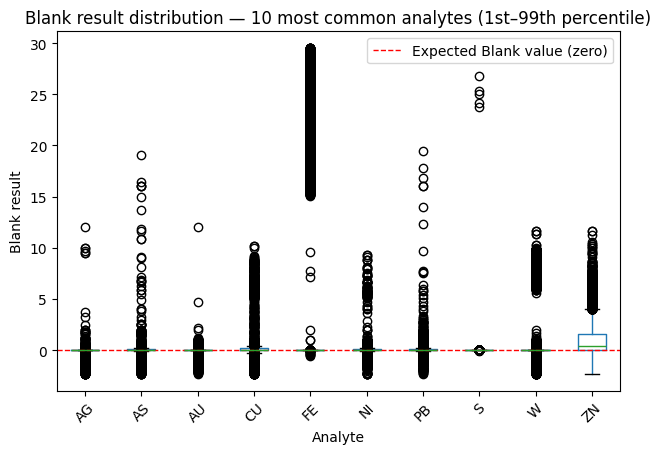

In [22]:
top_analytes = (
    analysis_df["ANALYTE_CODE"]
    .value_counts()
    .head(10)
    .index
)

plot_data = analysis_df[analysis_df["ANALYTE_CODE"].isin(top_analytes)].copy()

lower_limit = plot_data["NUMERIC_FINAL_VALUE"].quantile(0.01)
upper_limit = plot_data["NUMERIC_FINAL_VALUE"].quantile(0.99)

plot_data = plot_data[
    plot_data["NUMERIC_FINAL_VALUE"].between(lower_limit, upper_limit)
]

plt.figure(figsize=(12, 6))
plot_data.boxplot(column="NUMERIC_FINAL_VALUE", by="ANALYTE_CODE", grid=False)
plt.axhline(0, linestyle="--", color="red", linewidth=1, label="Expected Blank value (zero)")
plt.xlabel("Analyte")
plt.ylabel("Blank result")
plt.title("Blank result distribution — 10 most common analytes (1st–99th percentile)")
plt.suptitle("")
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()


**Interpretation:**

The distribution summary confirms that Blank data is right-skewed — the median is close to zero but the mean and 99th percentile are substantially higher, driven by occasional large positive results. This validates the use of median-based robust statistics rather than mean-based methods throughout this notebook.

The boxplot shows that most analytes are centred near zero, consistent with expected Blank behaviour. However, some analytes show a wider interquartile range and more high-value outliers. These analytes are likely to contribute a larger proportion of point-anomaly candidates.

**Important**: a positive Blank result is not automatically an anomaly. It must be assessed within the context of the same scheme, analyte, and unit to determine whether it is unusual relative to normal Blank behaviour for that measurement group.


## 7. Feature Engineering

This section derives the features used for both rule-based and machine-learning anomaly detection.

All features are computed **within comparable groups** defined by `SCHEME_CODE`, `ANALYTE_CODE`, and `UNIT_CODE`. This prevents results from different analytical methods, chemical elements, or measurement units from being compared with each other.

### Features derived

| Feature | Formula | Purpose |
|---|---|---|
| `TARGET_DEVIATION` | `NUMERIC_FINAL_VALUE − INTERNAL_TARGET_VALUE` | Distance from the expected Blank value |
| `GROUP_MEDIAN` | Median of group | Typical Blank result for this scheme/analyte/unit |
| `GROUP_MAD` | Median of absolute deviations from group median | Robust measure of normal spread (replaces standard deviation) |
| `ROBUST_Z_SCORE` | `0.6745 × (value − median) / MAD` | Standardised point-anomaly score; comparable to a Z-score but resistant to outliers |
| `ROLLING_MEDIAN` | Rolling median over 10 observations, min 3 | Local baseline level over time |
| `ROLLING_CHANGE` | `ROLLING_MEDIAN − GROUP_MEDIAN` | Direction and magnitude of baseline drift |

The factor **0.6745** scales the MAD-based score so that it is approximately equivalent to a standard Z-score under a normal distribution, making the threshold of 3 directly interpretable.

A `ROLLING_MEDIAN` window of 10 observations with a minimum of 3 is used. Groups with fewer than 3 observations will produce `NaN` for rolling features — this is expected behaviour and does not affect point-anomaly detection.


In [9]:
GROUP_COLUMNS = ["SCHEME_CODE", "ANALYTE_CODE", "UNIT_CODE"]

# Distance from the expected Blank target
analysis_df["TARGET_DEVIATION"] = (
    analysis_df["NUMERIC_FINAL_VALUE"] - analysis_df["INTERNAL_TARGET_VALUE"]
)

# Typical result within each comparable group
analysis_df["GROUP_MEDIAN"] = (
    analysis_df.groupby(GROUP_COLUMNS)["NUMERIC_FINAL_VALUE"]
    .transform("median")
)

# Median absolute deviation — robust spread measure
analysis_df["ABS_MEDIAN_DEVIATION"] = (
    analysis_df["NUMERIC_FINAL_VALUE"] - analysis_df["GROUP_MEDIAN"]
).abs()

analysis_df["GROUP_MAD"] = (
    analysis_df.groupby(GROUP_COLUMNS)["ABS_MEDIAN_DEVIATION"]
    .transform("median")
)

# Robust Z-score for point-anomaly detection
analysis_df["ROBUST_Z_SCORE"] = np.where(
    analysis_df["GROUP_MAD"] > 0,
    0.6745 * (analysis_df["NUMERIC_FINAL_VALUE"] - analysis_df["GROUP_MEDIAN"])
    / analysis_df["GROUP_MAD"],
    np.nan,
)

# Rolling median and drift score for collective anomaly detection
analysis_df["ROLLING_MEDIAN"] = (
    analysis_df.groupby(GROUP_COLUMNS)["NUMERIC_FINAL_VALUE"]
    .transform(lambda x: x.rolling(window=10, min_periods=3).median())
)

analysis_df["ROLLING_CHANGE"] = (
    analysis_df["ROLLING_MEDIAN"] - analysis_df["GROUP_MEDIAN"]
)

print("Feature engineering complete.")
print("Features added:", ["TARGET_DEVIATION", "GROUP_MEDIAN", "GROUP_MAD",
                          "ROBUST_Z_SCORE", "ROLLING_MEDIAN", "ROLLING_CHANGE"])
display(analysis_df[[
    "ANALYTE_CODE", "NUMERIC_FINAL_VALUE", "GROUP_MEDIAN",
    "GROUP_MAD", "ROBUST_Z_SCORE", "ROLLING_MEDIAN", "ROLLING_CHANGE"
]].head(10))


Feature engineering complete.
Features added: ['TARGET_DEVIATION', 'GROUP_MEDIAN', 'GROUP_MAD', 'ROBUST_Z_SCORE', 'ROLLING_MEDIAN', 'ROLLING_CHANGE']


,ANALYTE_CODE,NUMERIC_FINAL_VALUE,GROUP_MEDIAN,GROUP_MAD,ROBUST_Z_SCORE,ROLLING_MEDIAN,ROLLING_CHANGE
0,TE,0.00089,-0.00004,0.00095,0.660300,NaN,NaN
1,W,0.00143,-0.00010,0.00071,1.453500,NaN,NaN
2,SB,0.00083,0.00017,0.00061,0.729787,NaN,NaN
3,SB,0.00020,0.00017,0.00061,0.033172,NaN,NaN
4,TE,0.00120,-0.00004,0.00095,0.880400,NaN,NaN
5,W,-0.00016,-0.00010,0.00071,-0.057000,NaN,NaN
6,SB,0.00051,0.00017,0.00061,0.375951,0.000510,0.000340
7,W,-0.00023,-0.00010,0.00071,-0.123500,-0.000160,-0.000060
8,TE,0.00060,-0.00004,0.00095,0.454400,0.000890,0.000930
9,W,-0.00074,-0.00010,0.00071,-0.608000,-0.000195,-0.000095


## 8. Rule-Based Anomaly Flags

Three rule-based flags are applied, each corresponding to one of the Blank anomaly patterns defined in the project specification.

### Flag definitions

**Point anomaly** (`POINT_ANOMALY`):
An individual Blank result with a robust Z-score greater than 3. This threshold is equivalent to approximately 3 standard deviations above the group median under a normal distribution, but is resistant to the influence of the large outliers present in Blank data.

**Collective anomaly / Baseline drift** (`DRIFT_ANOMALY`):
A record where the rolling median of recent Blank results has moved more than 3 MADs above the long-run group median. This indicates that the Blank baseline has been persistently elevated — a pattern that may indicate developing contamination that is not yet visible in individual point checks.

**Contextual anomaly** (`CONTEXTUAL_ANOMALY`):
A record where the instrument responsible for the measurement has a typical Blank result more than 3 MADs above the comparable group median. This indicates that one instrument is producing systematically higher Blank results than others measuring the same analyte under the same scheme — a pattern that may indicate instrument-specific contamination or carryover.

All flags are conservative by design. Results flagged by rules alone do not confirm contamination and require analyst review.


In [10]:
# Point anomaly: unusually high individual result
analysis_df["POINT_ANOMALY"] = analysis_df["ROBUST_Z_SCORE"] > 3

# Collective anomaly: rolling baseline elevated above normal
analysis_df["DRIFT_ANOMALY"] = (
    (analysis_df["GROUP_MAD"] > 0)
    & (analysis_df["ROLLING_MEDIAN"] > analysis_df["GROUP_MEDIAN"] + 3 * analysis_df["GROUP_MAD"])
)

# Contextual anomaly: instrument-level median unusually elevated
INSTRUMENT_GROUP_COLUMNS = GROUP_COLUMNS + ["INSTRUMENT_CODE"]

analysis_df["INSTRUMENT_MEDIAN"] = (
    analysis_df
    .groupby(INSTRUMENT_GROUP_COLUMNS, dropna=False)["NUMERIC_FINAL_VALUE"]
    .transform("median")
)

analysis_df["INSTRUMENT_CONTEXT_SCORE"] = np.where(
    analysis_df["GROUP_MAD"] > 0,
    (analysis_df["INSTRUMENT_MEDIAN"] - analysis_df["GROUP_MEDIAN"]) / analysis_df["GROUP_MAD"],
    np.nan,
)

analysis_df["CONTEXTUAL_ANOMALY"] = (
    analysis_df["INSTRUMENT_CODE"].notna()
    & (analysis_df["INSTRUMENT_CONTEXT_SCORE"] > 3)
)

print("Point-anomaly candidates:     ", analysis_df["POINT_ANOMALY"].sum())
print("Baseline-drift candidates:    ", analysis_df["DRIFT_ANOMALY"].sum())
print("Instrument-context candidates:", analysis_df["CONTEXTUAL_ANOMALY"].sum())


Point-anomaly candidates:      12708
Baseline-drift candidates:     6268
Instrument-context candidates: 425


**Interpretation:**

- **Point anomalies** are the most common flag. A large count here is expected in Blank data because the distribution is right-skewed — even a modest number of high-value outliers will exceed the 3-MAD threshold.
- **Drift anomalies** indicate that the Blank baseline has been persistently elevated across a window of recent measurements. A sustained elevated baseline is more concerning than a single point anomaly because it suggests a developing rather than isolated contamination event.
- **Contextual anomalies** are the most targeted flag — they only apply to records where an instrument code is available, and they specifically identify instruments whose typical Blank behaviour differs from comparable measurements made by other instruments.

All counts are candidates only. The next step combines these flags with Isolation Forest to prioritise the most compelling cases for analyst review.


## 9. Drift Visualisation

Before applying machine learning, this section visualises the rolling Blank baseline over time for the analyte with the highest number of drift-anomaly candidates.

This plot shows:
- the individual Blank measurements (scatter points), coloured by whether they are flagged as point anomalies;
- the rolling median baseline (orange line), showing how the local Blank level changes over time;
- the long-run group median (dashed green line), representing normal Blank behaviour for this analyte;
- the drift threshold (dashed red line), set at 3 MADs above the group median.

When the rolling median line rises above the drift threshold line, those observations are flagged as drift-anomaly candidates.


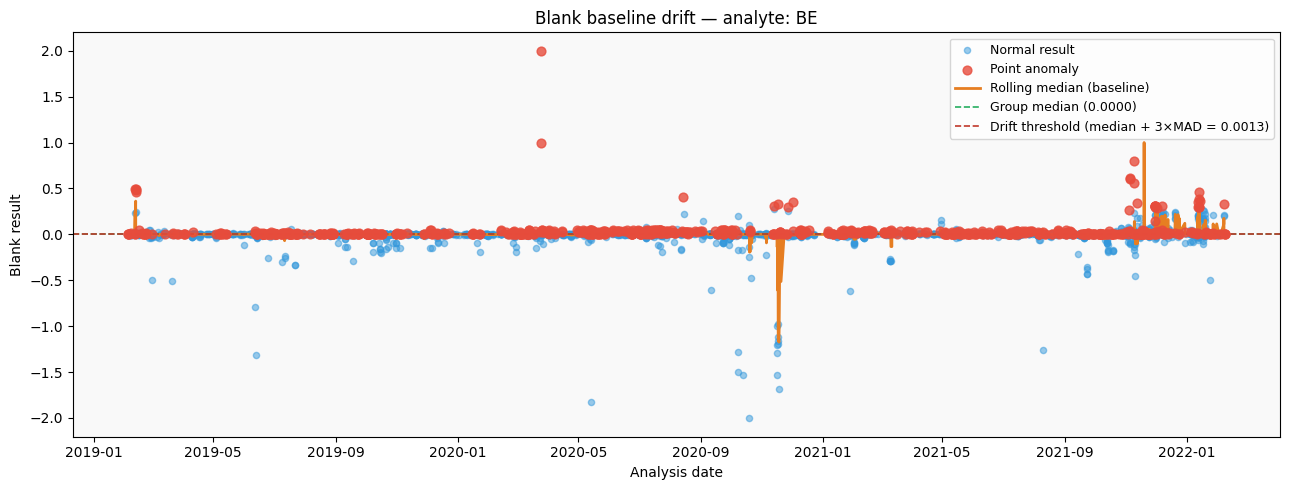

Analyte: BE
Group median: 0.000000
Group MAD:    0.000420
Drift threshold: 0.001260
Drift candidates: 587 of 3826 records


In [11]:
# Select the analyte with the most drift-anomaly candidates for visualisation
drift_analytes = (
    analysis_df[analysis_df["DRIFT_ANOMALY"]]
    .groupby("ANALYTE_CODE")
    .size()
    .sort_values(ascending=False)
)

if len(drift_analytes) > 0:
    top_drift_analyte = drift_analytes.index[0]
    plot_df = analysis_df[
        analysis_df["ANALYTE_CODE"] == top_drift_analyte
    ].sort_values("ANALYSED_DATE")

    group_median = plot_df["GROUP_MEDIAN"].iloc[0]
    group_mad    = plot_df["GROUP_MAD"].iloc[0]
    drift_threshold = group_median + 3 * group_mad

    fig, ax = plt.subplots(figsize=(13, 5))

    normal_pts = plot_df[~plot_df["POINT_ANOMALY"]]
    anomaly_pts = plot_df[plot_df["POINT_ANOMALY"]]

    ax.scatter(normal_pts["ANALYSED_DATE"], normal_pts["NUMERIC_FINAL_VALUE"],
               color="#3498db", alpha=0.5, s=20, label="Normal result")
    ax.scatter(anomaly_pts["ANALYSED_DATE"], anomaly_pts["NUMERIC_FINAL_VALUE"],
               color="#e74c3c", alpha=0.8, s=40, zorder=5, label="Point anomaly")
    ax.plot(plot_df["ANALYSED_DATE"], plot_df["ROLLING_MEDIAN"],
            color="#e67e22", linewidth=2, label="Rolling median (baseline)")
    ax.axhline(group_median, linestyle="--", color="#27ae60", linewidth=1.2,
               label=f"Group median ({group_median:.4f})")
    ax.axhline(drift_threshold, linestyle="--", color="#c0392b", linewidth=1.2,
               label=f"Drift threshold (median + 3×MAD = {drift_threshold:.4f})")

    ax.set_xlabel("Analysis date")
    ax.set_ylabel("Blank result")
    ax.set_title(f"Blank baseline drift — analyte: {top_drift_analyte}")
    ax.legend(fontsize=9)
    ax.set_facecolor("#f9f9f9")
    plt.tight_layout()
    plt.show()

    print(f"Analyte: {top_drift_analyte}")
    print(f"Group median: {group_median:.6f}")
    print(f"Group MAD:    {group_mad:.6f}")
    print(f"Drift threshold: {drift_threshold:.6f}")
    print(f"Drift candidates: {plot_df['DRIFT_ANOMALY'].sum()} of {len(plot_df)} records")
else:
    print("No drift anomaly candidates found in this dataset.")


## 10. Rule-Based Summary

This step combines the three individual flags into a single rule-based anomaly indicator. A record is flagged as a rule-based anomaly if it meets **any** of the three criteria.

The combined count is lower than the sum of individual flag counts because some records are flagged by more than one rule simultaneously — for example, a result may be both an unusually high individual result (point anomaly) and part of an elevated rolling baseline (drift anomaly).


In [12]:
analysis_df["RULE_BASED_ANOMALY"] = analysis_df[[
    "POINT_ANOMALY", "DRIFT_ANOMALY", "CONTEXTUAL_ANOMALY"
]].any(axis=1)

rule_summary = pd.DataFrame({
    "Rule": ["Point anomaly", "Baseline drift", "Instrument context", "Any rule-based anomaly"],
    "Count": [
        int(analysis_df["POINT_ANOMALY"].sum()),
        int(analysis_df["DRIFT_ANOMALY"].sum()),
        int(analysis_df["CONTEXTUAL_ANOMALY"].sum()),
        int(analysis_df["RULE_BASED_ANOMALY"].sum()),
    ]
})

display(rule_summary)


,Rule,Count
0,Point anomaly,12708
1,Baseline drift,6268
2,Instrument context,425
3,Any rule-based anomaly,16118


## 11. Isolation Forest

Isolation Forest is applied as the machine-learning anomaly detection layer.

### Why Isolation Forest for Blank data?

Isolation Forest is an unsupervised algorithm — it does not require labelled anomaly examples. This is appropriate for Blank data because the dataset does not contain confirmed contamination labels. The algorithm detects anomalies by measuring how easily a sample can be isolated from the rest of the data using random decision tree splits. Anomalies, being rare and different, are isolated in fewer splits.

### Feature inputs

Three positive-direction features are used, reflecting the Blank specification's focus on **unusually high** results:

| Feature | Source | Rationale |
|---|---|---|
| `POSITIVE_POINT_SCORE` | `ROBUST_Z_SCORE` clipped at 0 | Only upward deviations are relevant for Blank contamination |
| `POSITIVE_DRIFT_SCORE` | `ROLLING_CHANGE / GROUP_MAD` clipped at 0 | Captures upward baseline movement only |
| `POSITIVE_CONTEXT_SCORE` | `INSTRUMENT_CONTEXT_SCORE` clipped at 0 | Captures instruments with elevated Blank behaviour only |

Negative deviations (results below the group median) are set to zero because the Blank specification focuses on contamination, which produces elevated rather than suppressed results.

### Contamination rate

A conservative `contamination=0.01` (1%) is used because the Blank specification explicitly notes that false positives can cause unnecessary laboratory shutdowns or rework. `NaN` and infinite values are filled with zero before fitting.


In [13]:
analysis_df["POSITIVE_POINT_SCORE"] = analysis_df["ROBUST_Z_SCORE"].clip(lower=0)

analysis_df["DRIFT_SCORE"] = np.where(
    analysis_df["GROUP_MAD"] > 0,
    analysis_df["ROLLING_CHANGE"] / analysis_df["GROUP_MAD"],
    np.nan,
)
analysis_df["POSITIVE_DRIFT_SCORE"]   = analysis_df["DRIFT_SCORE"].clip(lower=0)
analysis_df["POSITIVE_CONTEXT_SCORE"] = analysis_df["INSTRUMENT_CONTEXT_SCORE"].clip(lower=0)

MODEL_FEATURES = [
    "POSITIVE_POINT_SCORE",
    "POSITIVE_DRIFT_SCORE",
    "POSITIVE_CONTEXT_SCORE",
]

model_data = (
    analysis_df[MODEL_FEATURES]
    .replace([np.inf, -np.inf], np.nan)
    .fillna(0)
)

isolation_forest = IsolationForest(
    n_estimators=100,
    contamination=0.01,
    random_state=RANDOM_STATE,
    n_jobs=-1,
)

analysis_df["ISOLATION_FOREST_ANOMALY"] = (
    isolation_forest.fit_predict(model_data) == -1
)
analysis_df["ISOLATION_FOREST_SCORE"] = (
    -isolation_forest.score_samples(model_data)
)

print("Isolation Forest complete.")
print(analysis_df["ISOLATION_FOREST_ANOMALY"].value_counts())
print(
    "\nCandidate rate:",
    round(analysis_df["ISOLATION_FOREST_ANOMALY"].mean() * 100, 2), "%"
)


Isolation Forest complete.
ISOLATION_FOREST_ANOMALY
False    395873
True       3991
Name: count, dtype: int64

Candidate rate: 1.0 %


,ANALYTE_CODE,AnomalyRatePct
10,BE,13.07
28,HF,7.55
9,BAO,7.14
19,CS,6.51
8,BA,5.80
67,TM,5.64
66,TL,5.56
15,CE,3.27
14,CD,2.48
3,AS,1.97


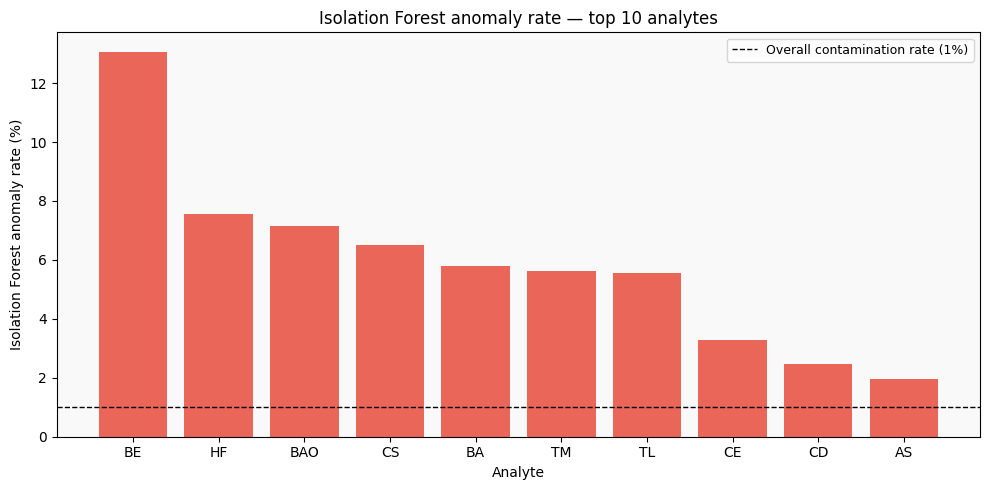

In [14]:
# Anomaly rate by analyte
anomalies_by_analyte = (
    analysis_df
    .groupby("ANALYTE_CODE")["ISOLATION_FOREST_ANOMALY"]
    .mean()
    .mul(100)
    .round(2)
    .rename("AnomalyRatePct")
    .reset_index()
    .sort_values("AnomalyRatePct", ascending=False)
    .head(10)
)

display(anomalies_by_analyte)

# Bar chart of anomaly rate by analyte
fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(anomalies_by_analyte["ANALYTE_CODE"], anomalies_by_analyte["AnomalyRatePct"],
       color="#e74c3c", alpha=0.85)
ax.axhline(1.0, linestyle="--", color="black", linewidth=1, label="Overall contamination rate (1%)")
ax.set_xlabel("Analyte")
ax.set_ylabel("Isolation Forest anomaly rate (%)")
ax.set_title("Isolation Forest anomaly rate — top 10 analytes")
ax.legend(fontsize=9)
ax.set_facecolor("#f9f9f9")
plt.tight_layout()
plt.show()


**Interpretation:**

Analytes with anomaly rates well above 1% contain a disproportionate share of the machine-learning candidates relative to the overall contamination rate. These analytes warrant closer attention during analyst review.

A high anomaly rate for a specific analyte does not automatically indicate contamination — it may also reflect naturally higher Blank variability for that element, a small number of total records, or differences in measurement units. Context within the same scheme and unit is always required.


## 12. Rule-Based vs Isolation Forest Comparison

This section compares the explainable rule-based flags with the Isolation Forest model to understand where the two approaches agree and where they diverge.

**Agreement between both methods** provides stronger evidence of genuine unusual Blank behaviour — the record is unusual both by explicit Blank-specific rules and by multivariate machine-learning assessment.

**Rule only** flags may represent real anomalies that are individually explainable but do not form an unusual multivariate combination. These are still valid candidates.

**Isolation Forest only** flags may represent unusual multivariate combinations not captured by the three individual rules — for example, a combination of moderately elevated point score, moderate drift, and moderate instrument score that individually do not cross any threshold.

**Neither** records are considered normal Blank behaviour under both approaches.


,Comparison,Count,Percent
0,Both,3409,0.85
1,Rule only,12709,3.18
2,Isolation Forest only,582,0.15
3,Neither,383164,95.82


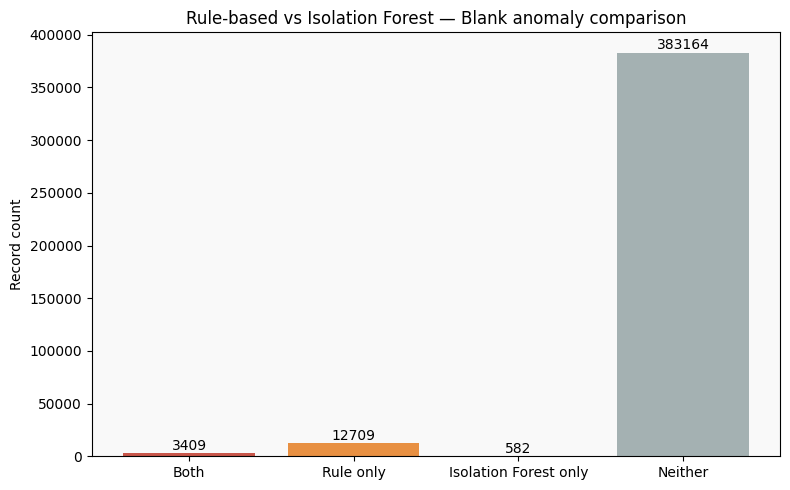

In [15]:
analysis_df["COMPARISON_GROUP"] = np.select(
    [
        analysis_df["RULE_BASED_ANOMALY"] &  analysis_df["ISOLATION_FOREST_ANOMALY"],
        analysis_df["RULE_BASED_ANOMALY"] & ~analysis_df["ISOLATION_FOREST_ANOMALY"],
       ~analysis_df["RULE_BASED_ANOMALY"] &  analysis_df["ISOLATION_FOREST_ANOMALY"],
    ],
    ["Both", "Rule only", "Isolation Forest only"],
    default="Neither",
)

comparison_summary = (
    analysis_df["COMPARISON_GROUP"]
    .value_counts()
    .reindex(["Both", "Rule only", "Isolation Forest only", "Neither"], fill_value=0)
    .rename_axis("Comparison")
    .reset_index(name="Count")
)
comparison_summary["Percent"] = (
    comparison_summary["Count"] / len(analysis_df) * 100
).round(2)

display(comparison_summary)

# Visualise the comparison
fig, ax = plt.subplots(figsize=(8, 5))
colours = ["#c0392b", "#e67e22", "#3498db", "#95a5a6"]
bars = ax.bar(comparison_summary["Comparison"], comparison_summary["Count"],
              color=colours, alpha=0.85)
for bar, count in zip(bars, comparison_summary["Count"]):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 50,
            str(count), ha="center", va="bottom", fontsize=10)
ax.set_ylabel("Record count")
ax.set_title("Rule-based vs Isolation Forest — Blank anomaly comparison")
ax.set_facecolor("#f9f9f9")
plt.tight_layout()
plt.show()


## 13. Final Candidate Results and Priority Ranking

Records are assigned a review priority based on the agreement between the rule-based and Isolation Forest approaches:

| Priority | Condition | Meaning |
|---|---|---|
| **High priority** | Flagged by both rules and Isolation Forest | Strong multivariate and rule-based evidence of unusual Blank behaviour |
| **Review** | Flagged by either rules or Isolation Forest | One method detected unusual behaviour — warrants analyst attention |
| **Not flagged** | Neither approach flagged the record | Consistent with normal Blank behaviour |

Within each priority group, records are sorted by Isolation Forest anomaly score (highest first) so the most statistically unusual records appear at the top of the review list.


In [16]:
analysis_df["REVIEW_PRIORITY"] = np.select(
    [
        analysis_df["RULE_BASED_ANOMALY"] & analysis_df["ISOLATION_FOREST_ANOMALY"],
        analysis_df["RULE_BASED_ANOMALY"] | analysis_df["ISOLATION_FOREST_ANOMALY"],
    ],
    ["High priority", "Review"],
    default="Not flagged",
)

priority_summary = (
    analysis_df["REVIEW_PRIORITY"]
    .value_counts()
    .rename_axis("ReviewPriority")
    .reset_index(name="Count")
)
display(priority_summary)


,ReviewPriority,Count
0,Not flagged,383164
1,Review,13291
2,High priority,3409


In [17]:
candidate_results = analysis_df[
    analysis_df["REVIEW_PRIORITY"] != "Not flagged"
].copy()

candidate_results = candidate_results.sort_values(
    ["REVIEW_PRIORITY", "ISOLATION_FOREST_SCORE"],
    ascending=[True, False],
)

display(
    candidate_results[[
        "ANALYSED_DATE", "SCHEME_CODE", "ANALYTE_CODE", "UNIT_CODE",
        "INSTRUMENT_CODE", "NUMERIC_FINAL_VALUE",
        "POINT_ANOMALY", "DRIFT_ANOMALY", "CONTEXTUAL_ANOMALY",
        "ISOLATION_FOREST_ANOMALY", "REVIEW_PRIORITY",
    ]].head(20)
)


,ANALYSED_DATE,SCHEME_CODE,ANALYTE_CODE,UNIT_CODE,INSTRUMENT_CODE,NUMERIC_FINAL_VALUE,POINT_ANOMALY,DRIFT_ANOMALY,CONTEXTUAL_ANOMALY,ISOLATION_FOREST_ANOMALY,REVIEW_PRIORITY
202664,2020-12-10 10:17:15,AR25_MS,CD,PPM,NaN,0.0080,True,True,False,True,High priority
388589,2021-12-24 12:23:08,AR25_MS,AS,PPM,NaN,0.4800,True,True,False,True,High priority
202469,2020-12-10 08:55:14,AR25_MS,CD,PPM,NaN,0.0072,True,True,False,True,High priority
371642,2021-11-09 20:14:10,AR25_MS,AS,PPM,NaN,0.4000,True,True,False,True,High priority
373568,2021-11-12 20:07:57,AR25_MS,AS,PPM,NaN,0.4000,True,True,False,True,High priority
376487,2021-11-19 17:19:58,AR25_MS,AS,PPM,NaN,0.4000,True,True,False,True,High priority
377458,2021-11-23 13:45:48,AR25_MS,AS,PPM,NaN,0.4000,True,True,False,True,High priority
377495,2021-11-23 14:46:37,AR25_MS,AS,PPM,NaN,0.4000,True,True,False,True,High priority
377513,2021-11-23 15:06:41,AR25_MS,AS,PPM,NaN,0.4000,True,True,False,True,High priority
378514,2021-11-25 09:52:16,AR25_MS,AS,PPM,NaN,0.4000,True,True,False,True,High priority


**How to read the results table:**

- `REVIEW_PRIORITY = High priority` means both the rule-based checks and Isolation Forest independently identified this record as unusual. These should be reviewed first.
- `POINT_ANOMALY = True` means the individual result was unusually high relative to similar Blank measurements in the same scheme, analyte, and unit.
- `DRIFT_ANOMALY = True` means this result occurred during a period when the rolling Blank baseline was elevated — indicating persistent rather than isolated contamination.
- `CONTEXTUAL_ANOMALY = True` means the instrument associated with this result has a systematically higher typical Blank result than comparable instruments. If `INSTRUMENT_CODE` is missing, this flag will always be `False` for that row.
- `ISOLATION_FOREST_ANOMALY = True` means the combination of point, drift, and instrument scores was unusual in multivariate space, even if no individual rule threshold was crossed.


## 14. Output Export

The final candidate results are exported to a CSV file for analyst review and downstream integration into the unified pipeline in Phase 2.

The output contains all flagged records with their anomaly flags, priority ranking, and Isolation Forest score, allowing the QC Chemist to filter, sort, and review the results outside the notebook environment.

Records marked `Not flagged` are excluded from the export — the output contains only candidate anomalies.


In [18]:
OUTPUT_PATH = Path("blank_anomaly_candidates.csv")

export_columns = [
    "ANALYSED_DATE", "SCHEME_CODE", "ANALYTE_CODE", "UNIT_CODE",
    "INSTRUMENT_CODE", "NUMERIC_FINAL_VALUE", "INTERNAL_TARGET_VALUE",
    "TARGET_DEVIATION", "ROBUST_Z_SCORE", "ROLLING_MEDIAN", "ROLLING_CHANGE",
    "POINT_ANOMALY", "DRIFT_ANOMALY", "CONTEXTUAL_ANOMALY",
    "RULE_BASED_ANOMALY", "ISOLATION_FOREST_ANOMALY",
    "ISOLATION_FOREST_SCORE", "REVIEW_PRIORITY",
]

candidate_results[export_columns].to_csv(OUTPUT_PATH, index=False)

print(f"Exported {len(candidate_results)} candidate records to: {OUTPUT_PATH.resolve()}")
print(f"High priority: {(candidate_results['REVIEW_PRIORITY'] == 'High priority').sum()}")
print(f"Review:        {(candidate_results['REVIEW_PRIORITY'] == 'Review').sum()}")


Exported 16700 candidate records to: /Users/ritumj/Documents/IFN735/Notebooks/blank_anomaly_candidates.csv
High priority: 3409
Review:        13291


## Summary

This notebook delivered a complete Blank sample anomaly detection MVP for Phase 1 of the Datamine QC Anomaly Detection project.

| Step | What was done |
|---|---|
| Extraction | Filtered Blank records from the full CCLAS export using `ANALYTICAL_TYPE = Blank` |
| Cleaning | Converted numeric fields, removed incomplete rows, retained missing instrument rows |
| Exploratory analysis | Confirmed right-skewed distribution, validated use of median-based methods |
| Feature engineering | Derived robust Z-score, group MAD, rolling median, and instrument context score |
| Rule-based detection | Applied point, drift, and contextual flags aligned with the Blank specification |
| Drift visualisation | Plotted rolling baseline over time for the highest-drift analyte |
| Isolation Forest | Applied 1% contamination rate using positive-direction Blank-specific features |
| Comparison | Compared rule-based and ML outputs across four agreement categories |
| Priority ranking | Assigned High priority / Review / Not flagged to all records |
| Export | Saved candidate anomalies to CSV for analyst review and Phase 2 integration |

**Phase 2 next steps:**
- Incorporate shift information if it becomes available in future CCLAS exports, to enable shift-based contextual analysis.
- Evaluate LOF as an additional layer for detecting subtle instrument-specific Blank elevation within dense analyte clusters.
- Integrate the Blank anomaly output into the unified multi-sample-type anomaly pipeline.
